# Throughput Comparison Across Sequence Lengths

This notebook measures and visualizes the **overall throughput** (tokens/second) of three language model architectures across increasing input sequence lengths:

| Model | Type | Size |
|-------|------|------|
| Qwen2.5-0.5B-Instruct | Transformer | ~0.5B |
| Mamba2-780m | SSM (Mamba-2) | ~780M |
| Falcon-H1 0.5B | Hybrid SSM | ~0.5B |

**Throughput** is defined as:

$$\text{throughput} = \frac{\text{input tokens} + \text{output tokens}}{\text{total wall-clock time (s)}}$$

Sequence lengths tested: `[1024, 2048, 4096, 8192, 16384, 24576, 32768]` tokens. Each run uses a fixed output length of 256 tokens.

The output figure is saved to `overall_throughput_comparison.png` for use as a paper figure.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

prof_dir = "."

## Load & Preprocess Data

Load generation timing results from CSV. The `model_name` column uses a prefixed format (`gen_<model>_...`); the model identifier is extracted and the data is filtered to the target sequence lengths.

In [34]:
# Load the data
df = pd.read_csv('generation_times.csv')

# Extract model names from model_name
df['model'] = df['model_name'].str.replace('gen_', '').str.split('_').str[0]

# Define sequence lengths
seq_lengths = [1024, 2048, 4096, 8192, 16384, 24576, 32768]


## Throughput Computation

Compute overall throughput as `(input_tokens + output_tokens) / total_time_seconds`. Results are pivoted into a wide table (rows = sequence length, columns = model) for easy inspection and plotting.

In [35]:
# Calculate overall throughput (total tokens / total time)
df['total_tokens'] = df['input_seq_length'] + df['output_tokens']
df['overall_throughput'] = df['total_tokens'] / df['total_time_seconds']

# Extract overall throughput data
overall_throughput_data = df[df['input_seq_length'].isin(seq_lengths)][['model', 'input_seq_length', 'overall_throughput']]
# print(overall_throughput_data)

# Pivot to get models as columns
overall_throughput_pivot = overall_throughput_data.pivot(index='input_seq_length', columns='model', values='overall_throughput')

print("Overall Throughput (total tokens / total time) for each model:")
print("=" * 70)
print(overall_throughput_pivot)
print("\n")

# Extract data for each model
qwen_overall_throughput = [overall_throughput_pivot.loc[seq, 'qwen25-instruct'] for seq in seq_lengths]
mamba_overall_throughput = [overall_throughput_pivot.loc[seq, 'mamba2'] for seq in seq_lengths]
falcon_overall_throughput = [overall_throughput_pivot.loc[seq, 'falcon-h1'] for seq in seq_lengths]

print("Overall Throughput values (tokens/second):")
print("-" * 70)
print(f"Qwen2.5-0.5B: {qwen_overall_throughput}")
print(f"Mamba2-780m: {mamba_overall_throughput}")
print(f"Falcon-H1 0.5B: {falcon_overall_throughput}")

Overall Throughput (total tokens / total time) for each model:
model               falcon-h1       mamba2  qwen25-instruct
input_seq_length                                           
1024               175.320040   352.675776       381.685923
2048               322.208638   643.038705       717.497246
4096               628.698810  1212.142039      1353.552201
8192              1189.300239  2174.560211      2585.943915
16384             2296.417465  4092.720040      4868.517329
24576             3316.852794  6109.340977      6976.138451
32768             4260.709924  7325.751796      2768.564412


Overall Throughput values (tokens/second):
----------------------------------------------------------------------
Qwen2.5-0.5B: [np.float64(381.685922668137), np.float64(717.4972458378761), np.float64(1353.552200525535), np.float64(2585.943914877985), np.float64(4868.517329055761), np.float64(6976.138450612867), np.float64(2768.5644122523763)]
Mamba2-780m: [np.float64(352.67577641084756), np.

## Visualization — Annotated Bar Chart

Grouped bar chart with axis labels and a legend for interactive exploration. Higher bars indicate better throughput. Note how SSM-based models maintain higher throughput at long contexts where the transformer's attention cost dominates.

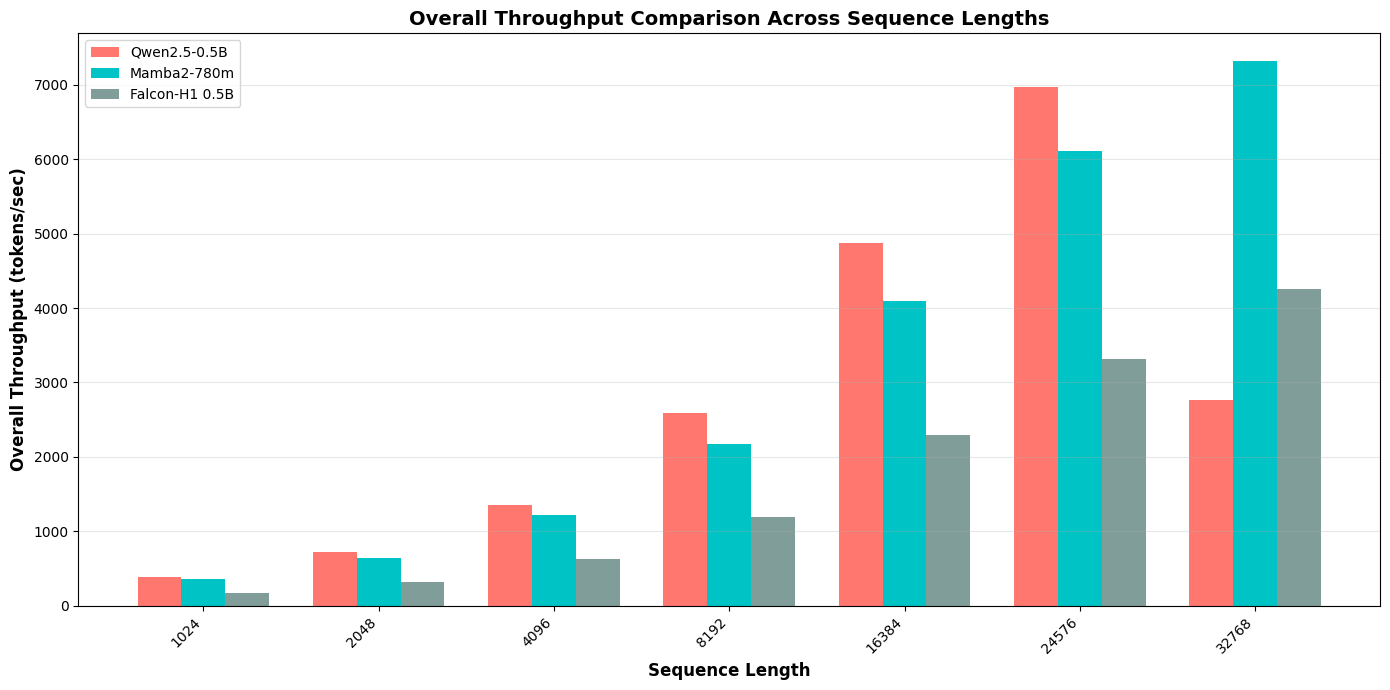

In [36]:
# Create bar plot for overall throughput
x = np.arange(len(seq_lengths))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width, qwen_overall_throughput, width, label='Qwen2.5-0.5B', color='#FF776E')
bars2 = ax.bar(x, mamba_overall_throughput, width, label='Mamba2-780m', color='#00C3C5')
bars3 = ax.bar(x + width, falcon_overall_throughput, width, label='Falcon-H1 0.5B', color='#809d9a')

# Customize plot
ax.set_xlabel('Sequence Length', fontsize=12, fontweight='bold')
ax.set_ylabel('Overall Throughput (tokens/sec)', fontsize=12, fontweight='bold')
ax.set_title('Overall Throughput Comparison Across Sequence Lengths', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(seq_lengths, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## Publication Figure

Clean version of the same plot — axis ticks and labels removed for use as a paper figure. The output is saved to `overall_throughput_comparison.png` at 300 DPI.

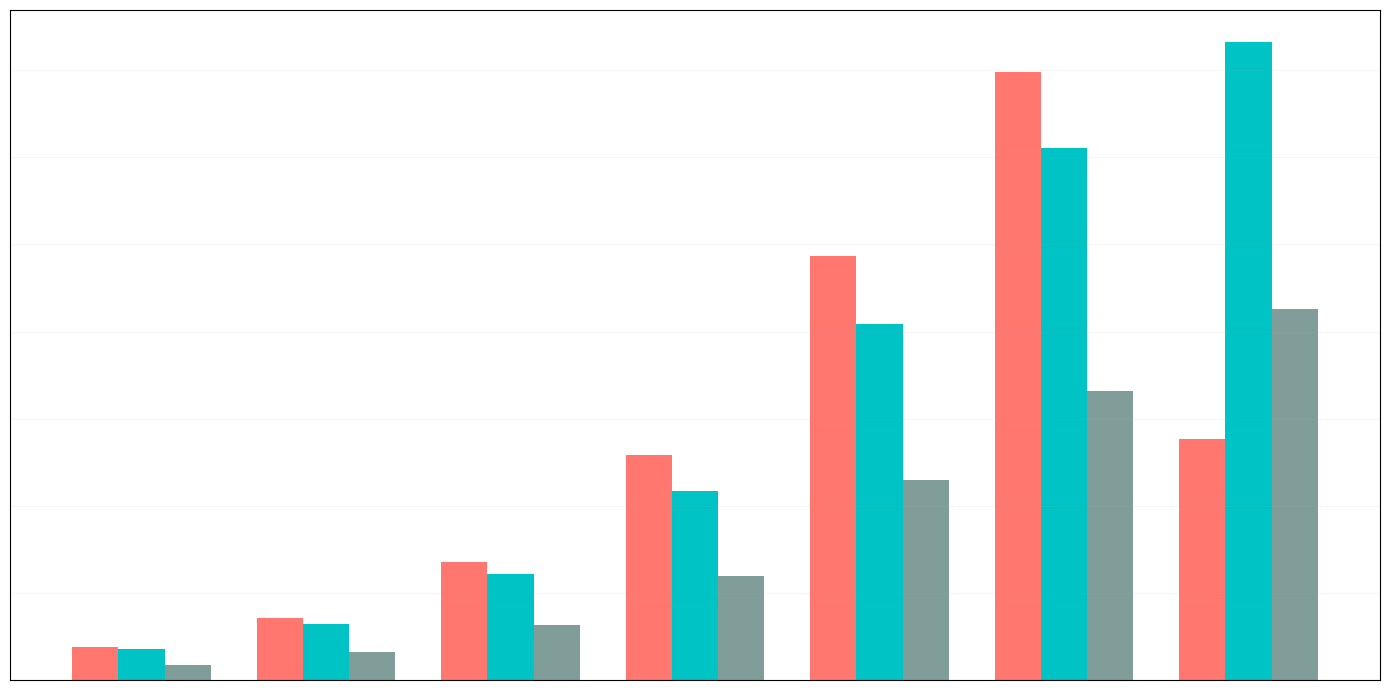

In [37]:
# Create bar plot for overall throughput without labels (for publication)
x = np.arange(len(seq_lengths))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width, qwen_overall_throughput, width, label='Qwen2.5-0.5B', color='#FF776E')
bars2 = ax.bar(x, mamba_overall_throughput, width, label='Mamba2-780m', color='#00C3C5')
bars3 = ax.bar(x + width, falcon_overall_throughput, width, label='Falcon-H1 0.5B', color='#809d9a')

# Customize plot
ax.grid(axis='y', alpha=0.1, which='both')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

plt.tight_layout()
plt.savefig(f"{prof_dir}/overall_throughput_comparison.png", dpi=300, bbox_inches='tight')
plt.show()